In [1]:
import numpy as np
import pandas
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist


{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',
  'pixel45',
  'pixel46',
  'pixel47

In [5]:
X, y = mnist['data'], mnist['target']
X.shape, y.shape

((70000, 784), (70000,))

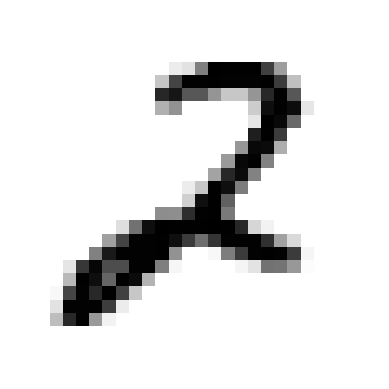

In [7]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
some_digit = X[36001]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap = matplotlib.cm.binary,
 interpolation="nearest")
plt.axis("off")
plt.show()

In [8]:
y[36001]

'2'

In [9]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [10]:
# Shuffle the training set
# This is important to ensure that the model does not learn any unintended patterns from the order of the data.
shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index]

In [17]:
#create a binary target variable for the digit 2
y_train_2 = (y_train == '2')
y_test_5 = (y_test == '2')


In [18]:
import numpy as np
print(np.unique(y_train_2))

[False  True]


In [19]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_2)


SGDClassifier(random_state=42)

In [20]:
# Check if the model can predict the digit 2
sgd_clf.predict([some_digit])

array([ True])

In [22]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_2, cv=3, scoring="accuracy")

array([0.9693 , 0.94375, 0.90425])

In [23]:
from sklearn.base import BaseEstimator
class Never2Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

never_2_clf = Never2Classifier()
cross_val_score(never_2_clf, X_train, y_train_2, cv=3, scoring="accuracy")

array([0.90145, 0.89865, 0.902  ])

In [24]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3)

In [26]:
y_train_pred

array([False, False, False, ..., False, False, False])

In [27]:
# confusion matrix
from sklearn.metrics import confusion_matrix
conf_mx = confusion_matrix(y_train_2, y_train_pred)
conf_mx

array([[51084,  2958],
       [  696,  5262]])

In [28]:
# Compute precision, recall, and F1 score
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve


precision = precision_score(y_train_2, y_train_pred)
recall = recall_score(y_train_2, y_train_pred)
f1 = f1_score(y_train_2, y_train_pred)
print(f"Precision: {precision:.3f}")  # How often is it correct when predicting '5'?
print(f"Recall: {recall:.3f}")      # How many actual '5's are detected?
print(f"F1 Score: {f1:.3f}")        # Balance of precision and recall

# Compute precision and recall for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train_2, y_train_pred)

Precision: 0.640
Recall: 0.883
F1 Score: 0.742


Plotting precision/recall tradeoff...


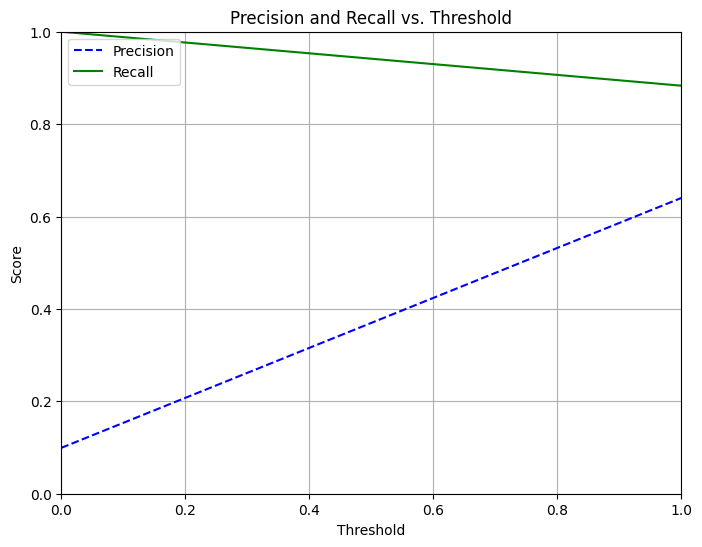

In [29]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision and Recall vs. Threshold")
    plt.legend(loc="upper left")
    plt.grid(True)
    plt.ylim([0, 1])
    plt.xlim([min(thresholds), max(thresholds)])
    plt.show()

print("Plotting precision/recall tradeoff...")
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

Plotting ROC curve...


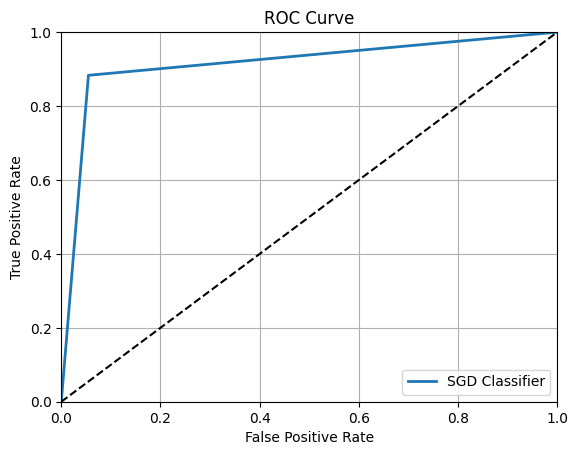

In [31]:
# plot roc curve
from sklearn.metrics import roc_curve
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.grid(True)
    plt.axis([0, 1, 0, 1])
    if label:
        plt.legend(loc='lower right')
fpr, tpr, thresholds = roc_curve(y_train_2, y_train_pred)
print("Plotting ROC curve...")
plot_roc_curve(fpr, tpr, label='SGD Classifier')